# ВКР


In [1]:
%pip install pandas numpy scikit-learn openpyxl matplotlib scipy joblib catboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.cluster import KMeans

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

from catboost import CatBoostRegressor


## 1. Настройки запуска и GPU

In [3]:
USE_GPU = True
GPU_DEVICE = "0"
RANDOM_STATE = 42

def get_catboost_task_type(use_gpu=True):
    if not use_gpu:
        return "CPU"
    try:
        test_model = CatBoostRegressor(
            iterations=5,
            depth=4,
            learning_rate=0.1,
            loss_function="RMSE",
            task_type="GPU",
            devices=GPU_DEVICE,
            verbose=False
        )
        X_tmp = pd.DataFrame({"x1": [0, 1, 2, 3], "x2": [1, 0, 1, 0]})
        y_tmp = [0.1, 0.9, 2.1, 2.9]
        test_model.fit(X_tmp, y_tmp)
        return "GPU"
    except Exception as e:
        print("GPU для CatBoost недоступен, переключаемся на CPU.")
        print("Причина:", str(e)[:300])
        return "CPU"

CATBOOST_TASK_TYPE = get_catboost_task_type(USE_GPU)
print("CatBoost task_type =", CATBOOST_TASK_TYPE)

CatBoost task_type = GPU


## 2. Загрузка и объединение данных

In [4]:
diag = pd.read_csv("ДиагРабота.csv", low_memory=False)
svod = pd.read_excel("Свод_КИМ_НИКО-22.xlsx")

diag["№"] = diag["№"].astype(str).str.strip()
svod["№"] = svod["№"].astype(str).str.strip()

df = diag.merge(svod, on="№", how="inner", suffixes=("_diag", "_svod"))
df.columns = df.columns.astype(str)

print("ДиагРабота:", diag.shape)
print("Свод:", svod.shape)
print("После merge:", df.shape)

ДиагРабота: (44367, 173)
Свод: (44567, 35)
После merge: (44567, 207)


In [5]:
target = "Проц_вып"
df[target] = pd.to_numeric(df[target], errors="coerce")
df = df[df[target].notna()].copy()

print(df[target].describe())
print("После очистки target:", df.shape)

count    44567.000000
mean        44.964471
std         15.732258
min          0.000000
25%         36.842105
50%         47.368421
75%         57.894737
max         94.736842
Name: Проц_вып, dtype: float64
После очистки target: (44567, 207)


## 3. Текстовые колонки и единый текст

In [6]:
text_cols = [
    "Расскажите немного о своей семье. Кто в неё входит? ",
    "Кем из членов семьи Вы гордитесь? Объясните, почему.",
    "Какие традиции существуют в Вашей семье?",
    "Что Вы обычно делаете вместе с другими членами семьи?",
    "Как называется Ваш населённый пункт?",
    "Какие достопримечательности есть в Вашем населённом пункте?",
    "Что, по Вашему мнению, необходимо сделать в первую очередь, чтобы улучшить жизнь в Вашем населённом пункте?",
    "Какими военными победами нашей страны Вы гордитесь?",
    "Каковы наиболее важные, на Ваш взгляд, научные открытия и технические достижения учёных нашей страны?",
    "Какие российские деятели искусства прошлого и настоящего известны всему миру?"
]

text_cols = [str(c) for c in text_cols]
existing_text_cols = [c for c in text_cols if c in df.columns]

for col in existing_text_cols:
    df[col] = df[col].fillna("").astype(str)

df["full_text"] = df[existing_text_cols].agg(" ".join, axis=1).str.strip()

print("Найдено текстовых колонок:", len(existing_text_cols))
print(df["full_text"].head(2).tolist())

Найдено текстовых колонок: 10
['мама, папа, дедушки, бабушки, тёти, дяди, сёстры, братья, двоюродные бабушки и дедушки, крёстная мама и крёстный папа, мои коты я горжусь своей мамой т.к. она занимается спортом, участвует в различных соревнованиях также она успевает всё делать на работе. она очень хорошая мама каждую осень мы ездим в горы, а летом мы едем на море или в санаторий, по выходным на костре жарим рыбу или мясо я часто готовлю с мамой, езжу на спорт, с папой ездим на футбол и едим роллы станица Каневская памятник Г. К. Нестеренко, памятник Ленину сделать ровные дороги, больше известных магазинов с хорошей, качественной одеждой, больше развлекательных мест и каруселей в ВОВ, первая мировая, русско-турецкая открытие Сибири  Ленин, Сталин, Пржевальский, Пушкин, Есенин, Гоголь', 'в мою семью входят мама , папа , бабушка , старший брат , младший брат , я , крестная ,тетя , бабушка , прабабушка,  я горжусь своими отцом и матерью так как они не имея ничего сумели вырастить трех детей

## 4. Безопасная база признаков

In [7]:
safe_base_cols = [
    "Класс",
    "ТИП_НП",
    "Размер_НП",
    "Пол",
    "Отметка_РУ",
    "Отметка_МА",
    "Члены_семьи",
    "Семья_другие_члены",
    "Семья_тип",
    "Семья_тип2",
    "Семья_тип_дих",
]
safe_base_cols = [c for c in safe_base_cols if c in df.columns]

X_base = df[safe_base_cols].copy()
X_base.columns = X_base.columns.astype(str)
y = df[target].copy()

print("Безопасные признаки:")
print(X_base.columns.tolist())
print("X_base:", X_base.shape)
print("y:", y.shape)

Безопасные признаки:
['ТИП_НП', 'Размер_НП', 'Отметка_РУ', 'Отметка_МА', 'Члены_семьи', 'Семья_другие_члены', 'Семья_тип', 'Семья_тип2', 'Семья_тип_дих']
X_base: (44567, 9)
y: (44567,)


## 5. Компактные ручные текстовые признаки

In [8]:
family_cols = [
    "Расскажите немного о своей семье. Кто в неё входит? ",
    "Кем из членов семьи Вы гордитесь? Объясните, почему.",
    "Какие традиции существуют в Вашей семье?",
    "Что Вы обычно делаете вместе с другими членами семьи?",
]
family_cols = [c for c in family_cols if c in df.columns]

place_cols = [
    "Как называется Ваш населённый пункт?",
    "Какие достопримечательности есть в Вашем населённом пункте?",
    "Что, по Вашему мнению, необходимо сделать в первую очередь, чтобы улучшить жизнь в Вашем населённом пункте?",
]
place_cols = [c for c in place_cols if c in df.columns]

country_cols = [
    "Какими военными победами нашей страны Вы гордитесь?",
    "Каковы наиболее важные, на Ваш взгляд, научные открытия и технические достижения учёных нашей страны?",
    "Какие российские деятели искусства прошлого и настоящего известны всему миру?"
]
country_cols = [c for c in country_cols if c in df.columns]

df["family_text"] = df[family_cols].agg(" ".join, axis=1).str.strip() if family_cols else ""
df["place_text"] = df[place_cols].agg(" ".join, axis=1).str.strip() if place_cols else ""
df["country_text"] = df[country_cols].agg(" ".join, axis=1).str.strip() if country_cols else ""

def count_words(text):
    text = str(text).strip()
    if not text:
        return 0
    return len(re.findall(r"\w+", text.lower(), flags=re.UNICODE))

def unique_words(text):
    words = re.findall(r"\w+", str(text).lower(), flags=re.UNICODE)
    return len(set(words))

def has_any(text, keywords):
    text = str(text).lower()
    return int(any(k in text for k in keywords))

df["full_text_chars"] = df["full_text"].astype(str).str.len()
df["full_text_words"] = df["full_text"].apply(count_words)
df["full_text_unique_words"] = df["full_text"].apply(unique_words)
df["full_text_nonempty"] = (df["full_text_words"] > 0).astype(int)

df["family_text_words"] = df["family_text"].apply(count_words)
df["place_text_words"] = df["place_text"].apply(count_words)
df["country_text_words"] = df["country_text"].apply(count_words)

df["mentions_mother"] = df["full_text"].apply(lambda x: has_any(x, ["мама", "мать"]))
df["mentions_father"] = df["full_text"].apply(lambda x: has_any(x, ["папа", "отец"]))
df["mentions_sibling"] = df["full_text"].apply(lambda x: has_any(x, ["брат", "сестра"]))
df["mentions_grand"] = df["full_text"].apply(lambda x: has_any(x, ["бабушка", "дедушка"]))
df["mentions_tradition"] = df["full_text"].apply(lambda x: has_any(x, ["традиц", "праздник", "вместе"]))
df["mentions_profession"] = df["full_text"].apply(lambda x: has_any(x, ["работ", "професс", "врач", "учитель", "инженер"]))
df["mentions_country"] = df["full_text"].apply(lambda x: has_any(x, ["росси", "страна", "родин", "город"]))
df["mentions_culture"] = df["full_text"].apply(lambda x: has_any(x, ["театр", "музей", "поэт", "писател", "искусств"]))
df["mentions_science"] = df["full_text"].apply(lambda x: has_any(x, ["наук", "учен", "изобрет", "открыти"]))
df["mentions_volunteer_like"] = df["full_text"].apply(lambda x: has_any(x, ["помощ", "волонтер", "добровол", "помогаем"]))

text_stat_cols = [
    "full_text_chars",
    "full_text_words",
    "full_text_unique_words",
    "full_text_nonempty",
    "family_text_words",
    "place_text_words",
    "country_text_words",
    "mentions_mother",
    "mentions_father",
    "mentions_sibling",
    "mentions_grand",
    "mentions_tradition",
    "mentions_profession",
    "mentions_country",
    "mentions_culture",
    "mentions_science",
    "mentions_volunteer_like",
]

df[text_stat_cols].head()

,full_text_chars,full_text_words,full_text_unique_words,full_text_nonempty,family_text_words,place_text_words,country_text_words,mentions_mother,mentions_father,mentions_sibling,mentions_grand,mentions_tradition,mentions_profession,mentions_country,mentions_culture,mentions_science,mentions_volunteer_like
0,760,119,92,1,82,23,14,1,1,1,0,0,1,0,0,1,0
1,478,77,63,1,57,8,12,1,1,1,1,1,0,1,0,0,0
2,336,50,46,1,24,13,13,1,1,1,1,0,0,1,1,0,0
3,536,76,67,1,42,15,19,1,1,1,0,1,1,1,1,0,0
4,345,54,49,1,34,7,13,1,0,1,1,0,0,1,0,0,0


## 6. Практический набор признаков

In [9]:
manual_practical_cols = safe_base_cols + text_stat_cols
manual_practical_cols = [c for c in manual_practical_cols if c in df.columns]
manual_practical_cols = list(dict.fromkeys(manual_practical_cols))

X_practical = df[manual_practical_cols].copy()
X_practical.columns = X_practical.columns.astype(str)

print("Практический набор признаков:")
print(X_practical.columns.tolist())
print("X_practical:", X_practical.shape)

Практический набор признаков:
['ТИП_НП', 'Размер_НП', 'Отметка_РУ', 'Отметка_МА', 'Члены_семьи', 'Семья_другие_члены', 'Семья_тип', 'Семья_тип2', 'Семья_тип_дих', 'full_text_chars', 'full_text_words', 'full_text_unique_words', 'full_text_nonempty', 'family_text_words', 'place_text_words', 'country_text_words', 'mentions_mother', 'mentions_father', 'mentions_sibling', 'mentions_grand', 'mentions_tradition', 'mentions_profession', 'mentions_country', 'mentions_culture', 'mentions_science', 'mentions_volunteer_like']
X_practical: (44567, 26)


## 7. Вспомогательные функции

In [10]:
def regression_metrics(y_true, y_pred, model_name="model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return pd.DataFrame([{"model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}])

def split_and_prepare(X, y, random_state=42):
    X = X.copy()
    X.columns = X.columns.astype(str)

    numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = [c for c in X.columns if c not in numeric_features]

    for col in categorical_features:
        X[col] = X[col].astype(str)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    for col in categorical_features:
        X_train[col] = X_train[col].astype(str)
        X_test[col] = X_test[col].astype(str)

    return X_train, X_test, y_train, y_test, numeric_features, categorical_features


## 8. Подготовка данных

In [11]:
X_train_base, X_test_base, y_train_base, y_test_base, num_base, cat_base = split_and_prepare(X_base, y)

base_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_base),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_base)
    ]
)

X_text = X_base.copy()
X_text["full_text"] = df["full_text"].fillna("").astype(str)
X_text.columns = X_text.columns.astype(str)

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_STATE
)

num_text = [c for c in X_text.select_dtypes(include=["number"]).columns.tolist() if c != "full_text"]
cat_text = [c for c in X_text.columns if c not in num_text + ["full_text"]]

for col in cat_text:
    X_train_text[col] = X_train_text[col].astype(str)
    X_test_text[col] = X_test_text[col].astype(str)

text_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_text),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_text),
        ("txt", Pipeline([("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3))]), "full_text")
    ]
)

X_train_pr, X_test_pr, y_train_pr, y_test_pr, num_pr, cat_pr = split_and_prepare(X_practical, y)

practical_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_pr),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_pr)
    ]
)

print(X_train_base.shape, X_train_text.shape, X_train_pr.shape)

(35653, 9) (35653, 10) (35653, 26)


## 9. Кластеризация учащихся по контекстным признакам

In [12]:
cluster_cols = [
    "Класс",
    "ТИП_НП",
    "Размер_НП",
    "Пол",
    "Отметка_РУ",
    "Отметка_МА",
    "Члены_семьи",
    "Семья_тип",
    "Семья_тип2",
    "full_text_chars",
    "full_text_words",
    "full_text_unique_words",
    "family_text_words",
    "place_text_words",
    "country_text_words",
]

cluster_cols = [c for c in cluster_cols if c in df.columns]
X_cluster = df[cluster_cols].copy()
X_cluster.columns = X_cluster.columns.astype(str)

cluster_num = X_cluster.select_dtypes(include=["number"]).columns.tolist()
cluster_cat = [c for c in X_cluster.columns if c not in cluster_num]

for c in cluster_cat:
    X_cluster[c] = X_cluster[c].astype(str)

cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), cluster_num),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cluster_cat)
    ]
)

X_cluster_ready = cluster_preprocessor.fit_transform(X_cluster)
print("Форма матрицы для кластеризации:", X_cluster_ready.shape)

Форма матрицы для кластеризации: (44567, 33)


In [13]:
cluster_scores = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_ready)
    sil = silhouette_score(X_cluster_ready, labels)
    inertia = km.inertia_
    cluster_scores.append({"k": k, "silhouette": sil, "inertia": inertia})

cluster_scores_df = pd.DataFrame(cluster_scores)
cluster_scores_df

,k,silhouette,inertia
0,2,0.326390,383305.598385
1,3,0.373366,283021.828521
2,4,0.224797,242537.170180
3,5,0.160761,223710.860438
4,6,0.138375,211008.504584


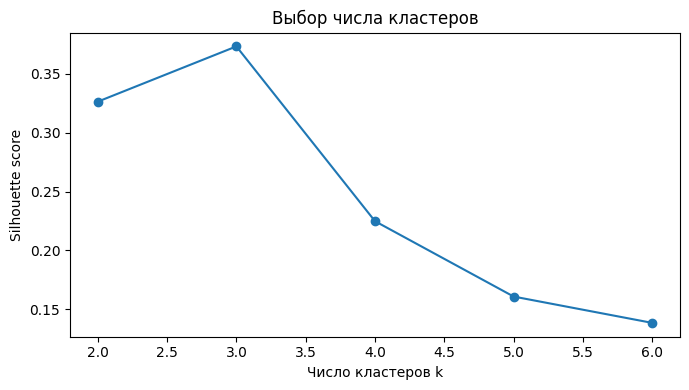

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(cluster_scores_df["k"], cluster_scores_df["silhouette"], marker="o")
plt.xlabel("Число кластеров k")
plt.ylabel("Silhouette score")
plt.title("Выбор числа кластеров")
plt.tight_layout()
plt.show()

In [15]:
best_k = int(cluster_scores_df.loc[cluster_scores_df["silhouette"].idxmax(), "k"])
print("Оптимальное число кластеров по silhouette:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["cluster_id"] = kmeans.fit_predict(X_cluster_ready).astype(str)

df["cluster_id"].value_counts().sort_index()

Оптимальное число кластеров по silhouette: 3


cluster_id
0     8998
1     1074
2    34495
Name: count, dtype: int64

In [17]:
# приведём отметки к числовому виду, если они есть
for col in ["Отметка_РУ", "Отметка_МА"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

agg_dict = {
    target: ["count", "mean", "median"],
    "full_text_words": "mean",
    "full_text_unique_words": "mean",
    "family_text_words": "mean",
    "place_text_words": "mean",
    "country_text_words": "mean",
}

if "Отметка_РУ" in df.columns:
    agg_dict["Отметка_РУ"] = "mean"

if "Отметка_МА" in df.columns:
    agg_dict["Отметка_МА"] = "mean"

cluster_profile = df.groupby("cluster_id").agg(agg_dict).round(3)
cluster_profile.columns = ["_".join([str(x) for x in col if x]).strip("_") for col in cluster_profile.columns]
cluster_profile = cluster_profile.reset_index()

cluster_profile

,cluster_id,Проц_вып_count,Проц_вып_mean,Проц_вып_median,full_text_words_mean,full_text_unique_words_mean,family_text_words_mean,place_text_words_mean,country_text_words_mean,Отметка_РУ_mean,Отметка_МА_mean
0,0,8998,57.445,57.895,94.901,79.213,54.828,20.654,19.419,104.427,93.225
1,1,1074,18.171,15.789,21.418,18.626,8.439,6.469,6.510,290.856,195.075
2,2,34495,42.543,42.105,39.281,35.798,22.500,8.525,8.256,85.196,82.281


## 10. Базовые модели без кластеризации

Сначала считаются результаты без признака `cluster_id`, чтобы затем честно сравнить их с моделями, где кластерная принадлежность добавлена как дополнительный контекстный признак.


In [18]:
results = pd.DataFrame(columns=["model", "MAE", "RMSE", "R2"])

In [19]:
linear_base_model = Pipeline([("preprocessor", base_preprocessor), ("model", LinearRegression())])
linear_base_model.fit(X_train_base, y_train_base)
pred_linear_base = linear_base_model.predict(X_test_base)
results = pd.concat([results, regression_metrics(y_test_base, pred_linear_base, "LinearRegression_base")], ignore_index=True)
results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728


In [20]:
linear_text_model = Pipeline([("preprocessor", text_preprocessor), ("model", LinearRegression())])
linear_text_model.fit(X_train_text, y_train_text)
pred_linear_text = linear_text_model.predict(X_test_text)
results = pd.concat([results, regression_metrics(y_test_text, pred_linear_text, "LinearRegression_base_text")], ignore_index=True)
results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,LinearRegression_base_text,6.130666,7.776278,0.755388


## 11. Подбор параметров: Ridge

In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_pipeline = Pipeline([("preprocessor", text_preprocessor), ("model", Ridge())])

ridge_param_grid = {
    "model__alpha": [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

ridge_search.fit(X_train_text, y_train_text)

print("Лучшие параметры Ridge:", ridge_search.best_params_)
print("Лучший CV R2 Ridge:", ridge_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры Ridge: {'model__alpha': 1.0}
Лучший CV R2 Ridge: 0.7621735549219018


In [22]:
best_ridge_model = ridge_search.best_estimator_
pred_best_ridge = best_ridge_model.predict(X_test_text)
results = pd.concat([results, regression_metrics(y_test_text, pred_best_ridge, "Ridge_base_text_tuned")], ignore_index=True)
results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,LinearRegression_base_text,6.130666,7.776278,0.755388
2,Ridge_base_text_tuned,6.072807,7.705738,0.759806


## 12. Подбор параметров: ElasticNet

In [23]:
elastic_pipeline = Pipeline([("preprocessor", text_preprocessor), ("model", ElasticNet(max_iter=8000))])

elastic_param_grid = {
    "model__alpha": [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3],
    "model__l1_ratio": [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
}

elastic_search = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

elastic_search.fit(X_train_text, y_train_text)

print("Лучшие параметры ElasticNet:", elastic_search.best_params_)
print("Лучший CV R2 ElasticNet:", elastic_search.best_score_)

Fitting 5 folds for each of 49 candidates, totalling 245 fits
Лучшие параметры ElasticNet: {'model__alpha': 0.0003, 'model__l1_ratio': 0.9}
Лучший CV R2 ElasticNet: 0.7593763187301503


In [24]:
best_elastic_model = elastic_search.best_estimator_
pred_best_elastic = best_elastic_model.predict(X_test_text)
results = pd.concat([results, regression_metrics(y_test_text, pred_best_elastic, "ElasticNet_base_text_tuned")], ignore_index=True)
results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,LinearRegression_base_text,6.130666,7.776278,0.755388
2,Ridge_base_text_tuned,6.072807,7.705738,0.759806
3,ElasticNet_base_text_tuned,6.129384,7.760667,0.756369


## 13. Подбор параметров: Lasso

In [25]:
lasso_pipeline = Pipeline([("preprocessor", text_preprocessor), ("model", Lasso(max_iter=8000))])

lasso_param_grid = {
    "model__alpha": [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]
}

lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    scoring="r2",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lasso_search.fit(X_train_text, y_train_text)

print("Лучшие параметры Lasso:", lasso_search.best_params_)
print("Лучший CV R2 Lasso:", lasso_search.best_score_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Лучшие параметры Lasso: {'model__alpha': 0.0003}
Лучший CV R2 Lasso: 0.7599754549904683


In [26]:
best_lasso_model = lasso_search.best_estimator_
pred_best_lasso = best_lasso_model.predict(X_test_text)
results = pd.concat([results, regression_metrics(y_test_text, pred_best_lasso, "Lasso_base_text_tuned")], ignore_index=True)
results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,LinearRegression_base_text,6.130666,7.776278,0.755388
2,Ridge_base_text_tuned,6.072807,7.705738,0.759806
3,ElasticNet_base_text_tuned,6.129384,7.760667,0.756369
4,Lasso_base_text_tuned,6.10061,7.741942,0.757543


## 14. Подбор параметров: Random Forest

In [27]:
rf_practical_pipeline = Pipeline([
    ("preprocessor", practical_preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_param_dist = {
    "model__n_estimators": randint(300, 1200),
    "model__max_depth": [8, 12, 16, 20, None],
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf": randint(1, 8),
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7]
}

rf_search = RandomizedSearchCV(
    estimator=rf_practical_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="r2",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_pr, y_train_pr)

print("Лучшие параметры RF practical:", rf_search.best_params_)
print("Лучший CV R2 RF practical:", rf_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры RF practical: {'model__max_depth': 20, 'model__max_features': 0.5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 9, 'model__n_estimators': 1024}
Лучший CV R2 RF practical: 0.6101865387382357


In [28]:
best_rf_practical_model = rf_search.best_estimator_
pred_best_rf_practical = best_rf_practical_model.predict(X_test_pr)
results = pd.concat([results, regression_metrics(y_test_pr, pred_best_rf_practical, "RandomForest_practical_tuned")], ignore_index=True)
results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,LinearRegression_base_text,6.130666,7.776278,0.755388
2,Ridge_base_text_tuned,6.072807,7.705738,0.759806
3,ElasticNet_base_text_tuned,6.129384,7.760667,0.756369
4,Lasso_base_text_tuned,6.10061,7.741942,0.757543
5,RandomForest_practical_tuned,7.77834,9.799922,0.61151


## 15. Подбор параметров: ExtraTrees

In [29]:
et_pipeline = Pipeline([
    ("preprocessor", practical_preprocessor),
    ("model", ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

et_param_dist = {
    "model__n_estimators": randint(300, 1200),
    "model__max_depth": [8, 12, 16, 20, None],
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf": randint(1, 8),
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7]
}

et_search = RandomizedSearchCV(
    estimator=et_pipeline,
    param_distributions=et_param_dist,
    n_iter=20,
    scoring="r2",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

et_search.fit(X_train_pr, y_train_pr)

print("Лучшие параметры ExtraTrees:", et_search.best_params_)
print("Лучший CV R2 ExtraTrees:", et_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры ExtraTrees: {'model__max_depth': None, 'model__max_features': 0.7, 'model__min_samples_leaf': 7, 'model__min_samples_split': 11, 'model__n_estimators': 766}
Лучший CV R2 ExtraTrees: 0.596293445366013


In [30]:
best_et_model = et_search.best_estimator_
pred_best_et = best_et_model.predict(X_test_pr)
results = pd.concat([results, regression_metrics(y_test_pr, pred_best_et, "ExtraTrees_practical_tuned")], ignore_index=True)
results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,LinearRegression_base_text,6.130666,7.776278,0.755388
2,Ridge_base_text_tuned,6.072807,7.705738,0.759806
3,ElasticNet_base_text_tuned,6.129384,7.760667,0.756369
4,Lasso_base_text_tuned,6.10061,7.741942,0.757543
5,RandomForest_practical_tuned,7.77834,9.799922,0.61151
6,ExtraTrees_practical_tuned,7.883142,9.957137,0.598945


## 16. Подбор параметров: HistGradientBoosting

In [31]:
X_hgb = pd.get_dummies(X_practical.copy(), drop_first=False)
X_train_hgb, X_test_hgb, y_train_hgb, y_test_hgb = train_test_split(
    X_hgb, y, test_size=0.2, random_state=RANDOM_STATE
)

hgb_param_dist = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [4, 6, 8, 10, None],
    "max_iter": randint(150, 500),
    "min_samples_leaf": randint(10, 60),
    "l2_regularization": [0.0, 0.1, 1.0]
}

hgb_search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    param_distributions=hgb_param_dist,
    n_iter=20,
    scoring="r2",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

hgb_search.fit(X_train_hgb, y_train_hgb)

print("Лучшие параметры HGB:", hgb_search.best_params_)
print("Лучший CV R2 HGB:", hgb_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры HGB: {'l2_regularization': 1.0, 'learning_rate': 0.1, 'max_depth': None, 'max_iter': 420, 'min_samples_leaf': 52}
Лучший CV R2 HGB: 0.6158409657571686


In [32]:
best_hgb_model = hgb_search.best_estimator_
pred_best_hgb = best_hgb_model.predict(X_test_hgb)
results = pd.concat([results, regression_metrics(y_test_hgb, pred_best_hgb, "HistGradientBoosting_practical_tuned")], ignore_index=True)
results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,LinearRegression_base_text,6.130666,7.776278,0.755388
2,Ridge_base_text_tuned,6.072807,7.705738,0.759806
3,ElasticNet_base_text_tuned,6.129384,7.760667,0.756369
4,Lasso_base_text_tuned,6.10061,7.741942,0.757543
5,RandomForest_practical_tuned,7.77834,9.799922,0.61151
6,ExtraTrees_practical_tuned,7.883142,9.957137,0.598945
7,HistGradientBoosting_practical_tuned,7.740525,9.760422,0.614636


## 17. Подбор параметров: CatBoost

In [33]:
X_cat = X_practical.copy()
X_cat.columns = X_cat.columns.astype(str)

cat_numeric = X_cat.select_dtypes(include=["number"]).columns.tolist()
cat_categorical = [c for c in X_cat.columns if c not in cat_numeric]

for c in cat_categorical:
    X_cat[c] = X_cat[c].astype(str)

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y, test_size=0.2, random_state=RANDOM_STATE
)

cat_features_idx = [X_cat.columns.get_loc(c) for c in cat_categorical]

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="R2",
    random_state=RANDOM_STATE,
    verbose=False,
    task_type=CATBOOST_TASK_TYPE,
    devices=GPU_DEVICE if CATBOOST_TASK_TYPE == "GPU" else None
)

cat_param_dist = {
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "iterations": [200, 400, 600, 800],
    "l2_leaf_reg": [1, 3, 5, 7, 9]
}

cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=cat_param_dist,
    n_iter=12,
    scoring="r2",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1
)

cat_search.fit(X_train_cat, y_train_cat, cat_features=cat_features_idx)

print("Лучшие параметры CatBoost:", cat_search.best_params_)
print("Лучший CV R2 CatBoost:", cat_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Default metric period is 5 because R2 is/are not implemented for GPU
Metric R2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because R2 is/are not implemented for GPU
Metric R2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because R2 is/are not implemented for GPU
Metric R2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because R2 is/are not implemented for GPU
Metric R2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because R2 is/are not implemented for GPU
Metric R2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because R2 is/are not implem

Лучшие параметры CatBoost: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 800, 'depth': 6}
Лучший CV R2 CatBoost: 0.6190518314555908


In [34]:
best_cat_model = cat_search.best_estimator_
pred_best_cat = best_cat_model.predict(X_test_cat)
results = pd.concat([results, regression_metrics(y_test_cat, pred_best_cat, "CatBoost_practical_tuned")], ignore_index=True)
results

,model,MAE,RMSE,R2
0,LinearRegression_base,11.619978,14.378268,0.163728
1,LinearRegression_base_text,6.130666,7.776278,0.755388
2,Ridge_base_text_tuned,6.072807,7.705738,0.759806
3,ElasticNet_base_text_tuned,6.129384,7.760667,0.756369
4,Lasso_base_text_tuned,6.10061,7.741942,0.757543
5,RandomForest_practical_tuned,7.77834,9.799922,0.61151
6,ExtraTrees_practical_tuned,7.883142,9.957137,0.598945
7,HistGradientBoosting_practical_tuned,7.740525,9.760422,0.614636
8,CatBoost_practical_tuned,7.701441,9.698453,0.619513


## 18. Сравнение моделей с кластеризацией и без неё

In [35]:
X_practical_cluster = X_practical.copy()
X_practical_cluster["cluster_id"] = df["cluster_id"].astype(str)

X_train_pr_cl, X_test_pr_cl, y_train_pr_cl, y_test_pr_cl, num_pr_cl, cat_pr_cl = split_and_prepare(X_practical_cluster, y)

practical_cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_pr_cl),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_pr_cl)
    ]
)

rf_cluster_model = Pipeline([
    ("preprocessor", practical_cluster_preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **{k.replace("model__", ""): v for k, v in rf_search.best_params_.items()}
    ))
])

rf_cluster_model.fit(X_train_pr_cl, y_train_pr_cl)
pred_rf_cluster = rf_cluster_model.predict(X_test_pr_cl)
cluster_compare = regression_metrics(y_test_pr_cl, pred_rf_cluster, "RandomForest_practical_plus_cluster")
cluster_compare

,model,MAE,RMSE,R2
0,RandomForest_practical_plus_cluster,7.780471,9.799848,0.611516


In [36]:
X_text_cluster = X_base.copy()
X_text_cluster["full_text"] = df["full_text"].fillna("").astype(str)
X_text_cluster["cluster_id"] = df["cluster_id"].astype(str)
X_text_cluster.columns = X_text_cluster.columns.astype(str)

X_train_text_cl, X_test_text_cl, y_train_text_cl, y_test_text_cl = train_test_split(
    X_text_cluster, y, test_size=0.2, random_state=RANDOM_STATE
)

num_text_cl = [c for c in X_text_cluster.select_dtypes(include=["number"]).columns.tolist() if c != "full_text"]
cat_text_cl = [c for c in X_text_cluster.columns if c not in num_text_cl + ["full_text"]]

for col in cat_text_cl:
    X_train_text_cl[col] = X_train_text_cl[col].astype(str)
    X_test_text_cl[col] = X_test_text_cl[col].astype(str)

text_cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_text_cl),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_text_cl),
        ("txt", Pipeline([("tfidf", TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3))]), "full_text")
    ]
)

ridge_cluster_model = Pipeline([
    ("preprocessor", text_cluster_preprocessor),
    ("model", Ridge(alpha=ridge_search.best_params_["model__alpha"]))
])

ridge_cluster_model.fit(X_train_text_cl, y_train_text_cl)
pred_ridge_cluster = ridge_cluster_model.predict(X_test_text_cl)
cluster_compare = pd.concat([
    cluster_compare,
    regression_metrics(y_test_text_cl, pred_ridge_cluster, "Ridge_base_text_plus_cluster")
], ignore_index=True)

cluster_compare

,model,MAE,RMSE,R2
0,RandomForest_practical_plus_cluster,7.780471,9.799848,0.611516
1,Ridge_base_text_plus_cluster,6.077397,7.705333,0.759831


In [37]:
cluster_compare_full = pd.concat([
    results[results["model"].isin(["RandomForest_practical_tuned", "Ridge_base_text_tuned"])],
    cluster_compare
], ignore_index=True).sort_values("RMSE").reset_index(drop=True)

cluster_compare_full

,model,MAE,RMSE,R2
0,Ridge_base_text_plus_cluster,6.077397,7.705333,0.759831
1,Ridge_base_text_tuned,6.072807,7.705738,0.759806
2,RandomForest_practical_plus_cluster,7.780471,9.799848,0.611516
3,RandomForest_practical_tuned,7.77834,9.799922,0.61151


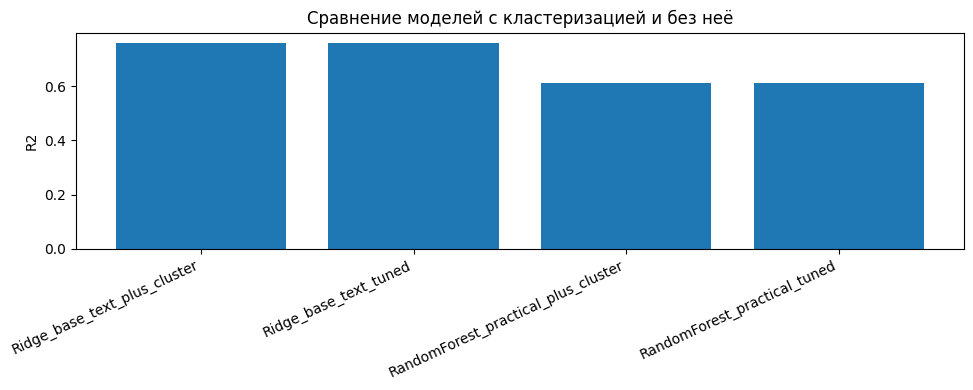

In [38]:
plt.figure(figsize=(10, 4))
plt.bar(cluster_compare_full["model"], cluster_compare_full["R2"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("R2")
plt.title("Сравнение моделей с кластеризацией и без неё")
plt.tight_layout()
plt.show()

## 19. Итоговые результаты

In [39]:
results = results.sort_values("RMSE").reset_index(drop=True)
results

,model,MAE,RMSE,R2
0,Ridge_base_text_tuned,6.072807,7.705738,0.759806
1,Lasso_base_text_tuned,6.10061,7.741942,0.757543
2,ElasticNet_base_text_tuned,6.129384,7.760667,0.756369
3,LinearRegression_base_text,6.130666,7.776278,0.755388
4,CatBoost_practical_tuned,7.701441,9.698453,0.619513
5,HistGradientBoosting_practical_tuned,7.740525,9.760422,0.614636
6,RandomForest_practical_tuned,7.77834,9.799922,0.61151
7,ExtraTrees_practical_tuned,7.883142,9.957137,0.598945
8,LinearRegression_base,11.619978,14.378268,0.163728


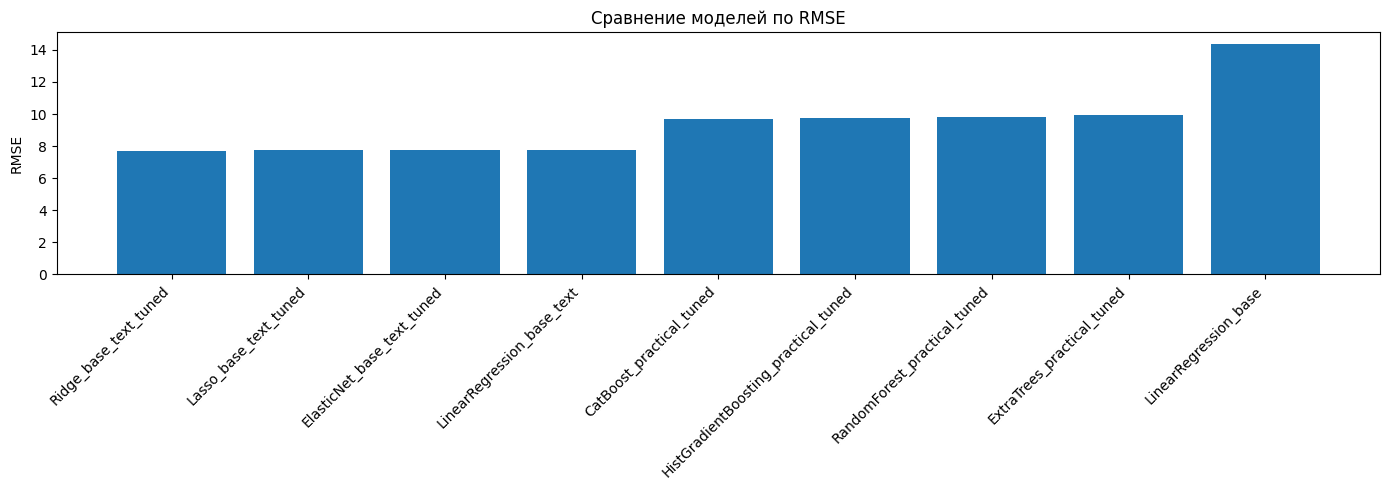

In [40]:
plt.figure(figsize=(14, 5))
plt.bar(results["model"], results["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Сравнение моделей по RMSE")
plt.tight_layout()
plt.show()

Лучшая модель: Ridge_base_text_tuned


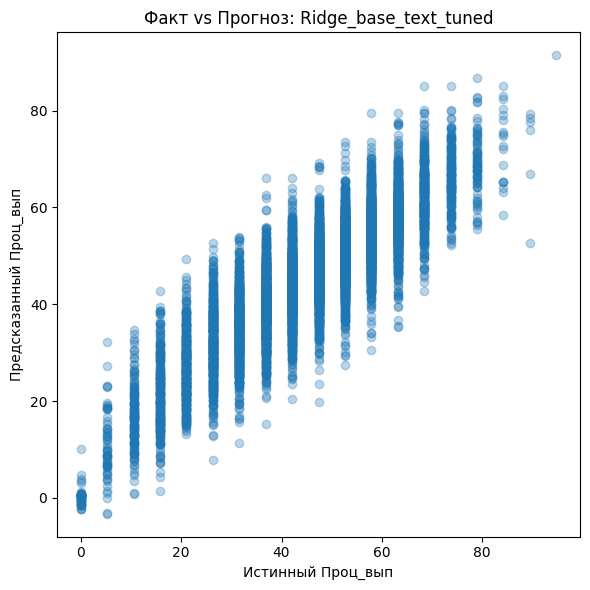

In [41]:
pred_map = {
    "LinearRegression_base": (pred_linear_base, y_test_base),
    "LinearRegression_base_text": (pred_linear_text, y_test_text),
    "Ridge_base_text_tuned": (pred_best_ridge, y_test_text),
    "ElasticNet_base_text_tuned": (pred_best_elastic, y_test_text),
    "Lasso_base_text_tuned": (pred_best_lasso, y_test_text),
    "RandomForest_practical_tuned": (pred_best_rf_practical, y_test_pr),
    "ExtraTrees_practical_tuned": (pred_best_et, y_test_pr),
    "HistGradientBoosting_practical_tuned": (pred_best_hgb, y_test_hgb),
    "CatBoost_practical_tuned": (pred_best_cat, y_test_cat),
}

best_model_name = results.iloc[0]["model"]
print("Лучшая модель:", best_model_name)

best_pred, best_y = pred_map[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(best_y, best_pred, alpha=0.3)
plt.xlabel("Истинный Проц_вып")
plt.ylabel("Предсказанный Проц_вып")
plt.title(f"Факт vs Прогноз: {best_model_name}")
plt.tight_layout()
plt.show()

## 20. Важность признаков

In [42]:
best_rf_fitted = best_rf_practical_model.named_steps["model"]
ohe_pr = best_rf_practical_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]

cat_feature_names_pr = ohe_pr.get_feature_names_out(cat_pr)
all_feature_names_pr = np.concatenate([num_pr, cat_feature_names_pr])

rf_practical_importances = pd.DataFrame({
    "feature": all_feature_names_pr,
    "importance": best_rf_fitted.feature_importances_
}).sort_values("importance", ascending=False)

rf_practical_importances.head(25)

,feature,importance
4,full_text_chars,0.358791
6,full_text_unique_words,0.217244
5,full_text_words,0.115816
10,country_text_words,0.072690
9,place_text_words,0.053107
8,family_text_words,0.051558
3,Семья_тип2,0.013073
0,Члены_семьи,0.011023
16,mentions_profession,0.004969
30,Размер_НП_6,0.004864


In [43]:
cat_importances = pd.DataFrame({
    "feature": X_cat.columns,
    "importance": best_cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

cat_importances.head(25)

,feature,importance
9,full_text_chars,31.731892
11,full_text_unique_words,22.335373
10,full_text_words,14.449907
15,country_text_words,10.118630
14,place_text_words,8.195288
13,family_text_words,3.271254
6,Семья_тип,1.910419
3,Отметка_МА,1.602480
4,Члены_семьи,0.972789
1,Размер_НП,0.889718


## 21. Сохранение результатов

In [44]:
results.to_csv("model_results_with_clustering.csv", index=False, encoding="utf-8-sig")
cluster_scores_df.to_csv("cluster_scores.csv", index=False, encoding="utf-8-sig")
cluster_profile.to_csv("cluster_profile.csv", encoding="utf-8-sig")
cluster_compare_full.to_csv("cluster_model_comparison.csv", index=False, encoding="utf-8-sig")
rf_practical_importances.to_csv("rf_practical_feature_importance_with_clustering.csv", index=False, encoding="utf-8-sig")
cat_importances.to_csv("catboost_feature_importance_with_clustering.csv", index=False, encoding="utf-8-sig")

best_row = results.iloc[0]
print("Лучший результат показала модель:", best_row["model"])
print(f"MAE = {best_row['MAE']:.4f}")
print(f"RMSE = {best_row['RMSE']:.4f}")
print(f"R2 = {best_row['R2']:.4f}")
print("\nФайлы сохранены.")

Лучший результат показала модель: Ridge_base_text_tuned
MAE = 6.0728
RMSE = 7.7057
R2 = 0.7598

Файлы сохранены.
